In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows',500)
np.random.seed(100)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/System-Threat-Forecaster/sample_submission.csv
/kaggle/input/System-Threat-Forecaster/train.csv
/kaggle/input/System-Threat-Forecaster/test.csv


In [2]:
allowed_libraries = ["NumPy","Pandas","Matplotlib","Scikit-learn","XGBoost","Seaborn","Imblearn","SciPy","Pickle","regex","Lightgbm","Plotly"]
df = pd.read_csv("/kaggle/input/System-Threat-Forecaster/train.csv")
dft = pd.read_csv("/kaggle/input/System-Threat-Forecaster/test.csv")
print(f"Training : {df.shape}\nTest : {dft.shape}")

Training : (100000, 76)
Test : (10000, 75)


In [3]:
df = df.drop("MachineID",axis=1)
dft = dft.drop("MachineID",axis=1)
X = df.drop("target",axis=1)
y = df["target"]
print(f"Training : {X.shape}\nLabel : {y.shape}\nTest : {dft.shape}")

Training : (100000, 74)
Label : (100000,)
Test : (10000, 74)


# EDA(Data Overview)

In [4]:
df.head()

,ProductName,EngineVersion,AppVersion,SignatureVersion,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,PlatformType,Processor,OSVersion,OSBuildNumber,OSProductSuite,OsPlatformSubRelease,OSBuildLab,SKUEditionName,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,MDC2FormFactor,DeviceFamily,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,PrimaryDiskType,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,ChassisType,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,PowerPlatformRole,InternalBatteryNumberOfCharges,NumericOSVersion,OSArchitecture,OSBranch,OSBuildNumberOnly,OSBuildRevisionOnly,OSEdition,OSSkuFriendlyName,OSInstallType,OSInstallLanguageID,OSUILocaleID,AutoUpdateOptionsName,IsPortableOS,OSGenuineState,LicenseActivationChannel,IsFlightsDisabled,FlightRing,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,DateAS,DateOS,target
0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1003.0,0,7.0,0,53447.0,1.0,1.0,1,51,120232.0,98.0,103,windows10,x86,10.0.0.0,14393,768,rs1,14393.2214.x86fre.rs1_release_1.180402-1758,Home,1.0,0,0.0,98.0,1.0,1.0,SmallTablet,Windows.Desktop,561.0,330367.0,4.0,5.0,1850.0,15028.0,SSD,14348.0,0,1024.0,Notebook,8.0,800.0,1280.0,Slate,1.420000e+02,10.0.14393.2214,x86,rs1_release,14393,2214,Core,CORE,Update,5.0,26,UNKNOWN,0,IS_GENUINE,Retail,0.0,Retail,513.0,21964.0,0,0.0,1,0,1.0,0.0,6.0,2018-09-10 10:11:00,2018-04-17,0
1,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1465.0,0,7.0,0,53447.0,1.0,1.0,1,141,112854.0,167.0,227,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,AllInOne,Windows.Desktop,2668.0,25212.0,4.0,5.0,2407.0,953869.0,HDD,952592.0,1,4096.0,AllinOne,19.4,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.228,amd64,rs4_release,17134,228,Professional,PROFESSIONAL,UUPUpgrade,9.0,34,FullAuto,0,IS_GENUINE,OEM:DM,0.0,Retail,628.0,44548.0,1,0.0,0,0,0.0,0.0,10.0,2018-08-16 00:01:00,2018-08-14,1
2,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1546.0,0,7.0,0,53447.0,1.0,1.0,1,51,41759.0,98.0,103,windows10,x64,10.0.0.0,17134,768,rs4,17134.1.amd64fre.rs4_release.180410-1804,Home,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,3035.0,263666.0,4.0,5.0,2719.0,228936.0,SSD,228321.0,1,8192.0,Desktop,24.0,1920.0,1080.0,Desktop,4.294967e+09,10.0.17134.285,amd64,rs4_release,17134,285,Core,CORE,Reset,5.0,26,FullAuto,0,IS_GENUINE,OEM:NONSLP,0.0,Retail,142.0,9414.0,0,0.0,0,0,0.0,1.0,6.0,2018-09-20 23:20:00,2018-09-11,1
3,win8defender,1.1.15200.1,4.12.17007.18011,1.275.1141.0,0,7.0,0,46413.0,2.0,1.0,1,68,19507.0,276.0,74,windows10,x64,10.0.0.0,15063,768,rs2,15063.0.amd64fre.rs2_release.170317-1834,Home,1.0,0,0.0,108.0,1.0,1.0,Notebook,Windows.Desktop,2102.0,242491.0,4.0,5.0,3410.0,1907729.0,HDD,1890776.0,0,8192.0,Notebook,15.5,1366.0,768.0,Mobile,0.000000e+00,10.0.15063.850,amd64,rs2_release,15063,850,Core,CORE,Upgrade,7.0,30,UNKNOWN,0,IS_GENUINE,OEM:DM,0.0,Retail,554.0,33060.0,1,0.0,0,0,0.0,0.0,12.0,2018-09-14 00:32:00,2018-01-03,1
4,win8defender,1.1.15200.1,4.13.17134.228,1.275.1283.0,0,7.0,0,40466.0,2.0,1.0,1,43,117801.0,53.0,42,windows10,x86,10.0.0.0,17134,256,rs4,17134.1.x86fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,2668.0,257309.0,2.0,5.0,4322.0,305245.0,HDD,52804.0,0,2048.0,Desktop,20.0,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.285,x86,rs4_release,17134,285,Professional,PROFESSIONAL,UUPUpgrade,37.0,158,FullAuto,0,IS_GENUINE,Retail,0.0,Retail,628.0,13224.0,0,0.0,0,0,0.0,1.0,7.0,2018-09-15 19:34:00,2018-09-11,0


In [5]:
df.tail()

,ProductName,EngineVersion,AppVersion,SignatureVersion,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,PlatformType,Processor,OSVersion,OSBuildNumber,OSProductSuite,OsPlatformSubRelease,OSBuildLab,SKUEditionName,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,MDC2FormFactor,DeviceFamily,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,PrimaryDiskType,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,ChassisType,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,PowerPlatformRole,InternalBatteryNumberOfCharges,NumericOSVersion,OSArchitecture,OSBranch,OSBuildNumberOnly,OSBuildRevisionOnly,OSEdition,OSSkuFriendlyName,OSInstallType,OSInstallLanguageID,OSUILocaleID,AutoUpdateOptionsName,IsPortableOS,OSGenuineState,LicenseActivationChannel,IsFlightsDisabled,FlightRing,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,DateAS,DateOS,target
99995,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1582.0,0,7.0,0,68585.0,2.0,1.0,1,43,71228.0,53.0,42,windows10,x64,10.0.0.0,16299,256,rs3,16299.431.amd64fre.rs3_release_svc_escrow.1805...,Pro,1.0,0,0.0,117.0,1.0,1.0,Desktop,Windows.Desktop,4909.0,317701.0,4.0,5.0,2615.0,122104.0,SSD,121488.0,0,8192.0,Desktop,23.8,1920.0,1080.0,Desktop,4.294967e+09,10.0.17134.319,amd64,rs4_release,17134,319,Professional,PROFESSIONAL,UUPUpgrade,37.0,158,FullAuto,0,IS_GENUINE,Retail,0.0,Retail,142.0,25740.0,0,0.0,0,0,0.0,1.0,7.0,2018-09-21 00:59:00,2018-09-20,0
99996,win8defender,1.1.15100.1,4.18.1806.18062,1.273.1156.0,0,7.0,0,11280.0,2.0,1.0,1,137,137066.0,160.0,74,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,Notebook,Windows.Desktop,1443.0,260853.0,4.0,5.0,2529.0,476940.0,HDD,475637.0,0,4096.0,Laptop,13.2,1366.0,768.0,Mobile,0.000000e+00,10.0.17134.165,amd64,rs4_release,17134,165,Professional,PROFESSIONAL,UUPUpgrade,8.0,31,FullAuto,0,IS_GENUINE,Retail,0.0,Retail,355.0,20900.0,0,0.0,0,0,0.0,0.0,3.0,2018-08-10 07:23:00,2018-07-10,0
99997,win8defender,1.1.15200.1,4.18.1807.18075,1.275.209.0,0,7.0,0,53447.0,1.0,1.0,1,142,74924.0,157.0,68,windows10,x64,10.0.0.0,16299,256,rs3,16299.15.amd64fre.rs3_release.170928-1534,Pro,1.0,0,0.0,111.0,1.0,1.0,Desktop,Windows.Desktop,2102.0,250496.0,4.0,5.0,2719.0,953869.0,HDD,532690.0,0,4096.0,Desktop,18.5,1366.0,768.0,Desktop,4.294967e+09,10.0.16299.309,amd64,rs3_release,16299,309,Professional,PROFESSIONAL,Upgrade,8.0,31,Notify,0,IS_GENUINE,OEM:DM,0.0,Retail,486.0,51605.0,1,0.0,0,0,0.0,1.0,1.0,2018-08-26 23:51:00,2018-03-13,1
99998,win8defender,1.1.14901.4,4.16.17656.18052,1.269.641.0,0,7.0,0,53447.0,1.0,1.0,1,139,87570.0,158.0,74,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,Notebook,Windows.Desktop,3150.0,313499.0,4.0,5.0,3032.0,976762.0,SSD,497353.0,0,16384.0,Laptop,13.5,3000.0,2000.0,Slate,4.500000e+01,10.0.17134.48,amd64,rs4_release,17134,48,Professional,PROFESSIONAL,UUPUpgrade,8.0,31,Notify,0,IS_GENUINE,OEM:DM,0.0,Unknown,677.0,18669.0,1,0.0,1,1,1.0,0.0,1.0,2018-06-04 17:13:00,2018-05-08,0
99999,win8defender,1.1.15000.2,4.18.1806.18062,1.271.1003.0,0,7.0,0,7945.0,2.0,1.0,1,100,4110.0,224.0,75,windows10,x64,10.0.0.0,17134,768,rs4,17134.1.amd64fre.rs4_release.180410-1804,Home,1.0,0,0.0,137.0,1.0,1.0,Notebook,Windows.Desktop,1443.0,256682.0,4.0,5.0,3026.0,953869.0,HDD,937373.0,0,8192.0,Notebook,15.5,1366.0,768.0,Mobile,0.000000e+00,10.0.17134.228,amd64,rs4_release,17134,228,Core,CORE,UUPUpgrade,8.0,31,FullAuto,0,IS_GENUINE,OEM:DM,0.0,Retail,355.0,7203.0,1,0.0,0,0,0.0,1.0,11.0,2018-07-14 15:36:00,2018-08-14,0


In [6]:
df.describe()

,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,OSBuildNumber,OSProductSuite,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,InternalBatteryNumberOfCharges,OSBuildNumberOnly,OSBuildRevisionOnly,OSInstallLanguageID,OSUILocaleID,IsPortableOS,IsFlightsDisabled,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,target
count,100000.0,99934.000000,100000.000000,99924.000000,99924.000000,99924.000000,100000.000000,100000.000000,99377.000000,100000.000000,100000.000000,100000.000000,100000.000000,99924.000000,100000.0,99019.000000,99893.000000,99834.000000,99981.000000,99788.000000,99772.000000,99915.000000,99915.000000,99915.000000,9.989000e+04,9.989000e+04,100000.00000,99849.000000,99928.000000,99928.000000,99928.000000,9.948500e+04,100000.000000,100000.000000,99887.000000,100000.000000,100000.000000,99674.0,99624.000000,99666.000000,100000.000000,99980.000000,100000.000000,100000.000000,99866.000000,99441.000000,99441.000000,100000.000000
mean,0.0,6.848430,0.017620,47975.710440,1.326528,1.018264,0.996780,108.078790,81029.938587,169.741630,122.695100,15917.208720,578.403380,0.955326,0.0,0.000505,124.053848,0.980067,0.996569,2209.573265,238780.914154,4.011500,4.530711,2367.693069,5.158619e+05,3.819905e+05,0.08140,6132.087442,16.708674,1552.230416,898.253192,1.118069e+09,15990.596350,986.531360,14.519267,60.030870,0.000520,0.0,401.987613,32942.648044,0.495690,0.003841,0.128470,0.040580,0.058398,0.296668,7.875866,0.505250
std,0.0,1.015166,0.131566,13803.321533,0.520681,0.155291,0.056654,63.062151,48944.027074,89.188929,69.242252,1943.421132,247.240971,0.206588,0.0,0.022466,33.535395,0.139771,0.266669,1300.863891,71708.483379,2.033075,1.288050,837.822392,3.525624e+05,3.246240e+05,0.27345,4813.882548,6.031598,363.438980,213.695880,1.884682e+09,1810.756601,2971.429862,10.142233,44.715508,0.022798,0.0,221.318891,21151.970827,0.499984,0.061855,0.334614,0.197316,0.234496,0.456791,4.562533,0.499975
min,0.0,0.000000,0.000000,39.000000,1.000000,0.000000,0.000000,1.000000,7.000000,1.000000,1.000000,7601.000000,16.000000,0.000000,0.0,0.000000,39.000000,0.000000,0.000000,46.000000,22.000000,1.000000,1.000000,3.000000,1.228800e+04,1.088000e+04,0.00000,512.000000,5.300000,400.000000,300.000000,0.000000e+00,10240.000000,0.000000,1.000000,5.000000,0.000000,0.0,2.000000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.0,7.000000,0.000000,49480.000000,1.000000,1.000000,1.000000,51.000000,36694.000000,89.000000,74.000000,16299.000000,256.000000,1.000000,0.0,0.000000,111.000000,1.000000,1.000000,1443.000000,189586.000000,2.000000,5.000000,1998.000000,2.441980e+05,1.208410e+05,0.00000,4096.000000,13.900000,1366.000000,768.000000,0.000000e+00,16299.000000,167.000000,8.000000,31.000000,0.000000,0.0,142.000000,13020.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,0.0,7.000000,0.000000,53447.000000,1.000000,1.000000,1.000000,97.000000,82373.000000,181.000000,88.000000,16299.000000,768.000000,1.000000,0.0,0.000000,135.000000,1.000000,1.000000,2102.000000,246528.000000,4.000000,5.000000,2503.000000,4.769400e+05,2.567655e+05,0.00000,4096.000000,15.500000,1366.000000,768.000000,0.000000e+00,16299.000000,285.000000,9.000000,34.000000,0.000000,0.0,500.000000,33066.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000
75%,0.0,7.000000,0.000000,53447.000000,2.000000,1.000000,1.000000,162.000000,122835.000000,267.000000,182

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 75 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   ProductName                         100000 non-null  object 
 1   EngineVersion                       100000 non-null  object 
 2   AppVersion                          100000 non-null  object 
 3   SignatureVersion                    100000 non-null  object 
 4   IsBetaUser                          100000 non-null  int64  
 5   RealTimeProtectionState             99934 non-null   float64
 6   IsPassiveModeEnabled                100000 non-null  int64  
 7   AntivirusConfigID                   99924 non-null   float64
 8   NumAntivirusProductsInstalled       99924 non-null   float64
 9   NumAntivirusProductsEnabled         99924 non-null   float64
 10  HasTpm                              100000 non-null  int64  
 11  CountryID                  

In [8]:
print("\nMissing values by column:")
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values[missing_values > 0])


Missing values by column:
SMode                                 981
CityID                                623
RegionIdentifier                      559
IsGamer                               559
InternalBatteryNumberOfCharges        515
FirmwareManufacturerID                376
FirmwareVersionID                     334
IsFlightsDisabled                     326
OEMModelID                            228
OEMNameID                             212
FirewallEnabled                       166
TotalPhysicalRAMMB                    151
IsAlwaysOnAlwaysConnectedCapable      134
OSInstallLanguageID                   113
SystemVolumeCapacityMB                110
PrimaryDiskCapacityMB                 110
IEVersionID                           107
ProcessorCoreCount                     85
ProcessorManufacturerID                85
ProcessorModelID                       85
NumAntivirusProductsEnabled            76
NumAntivirusProductsInstalled          76
AntivirusConfigID                      76
IsSyste

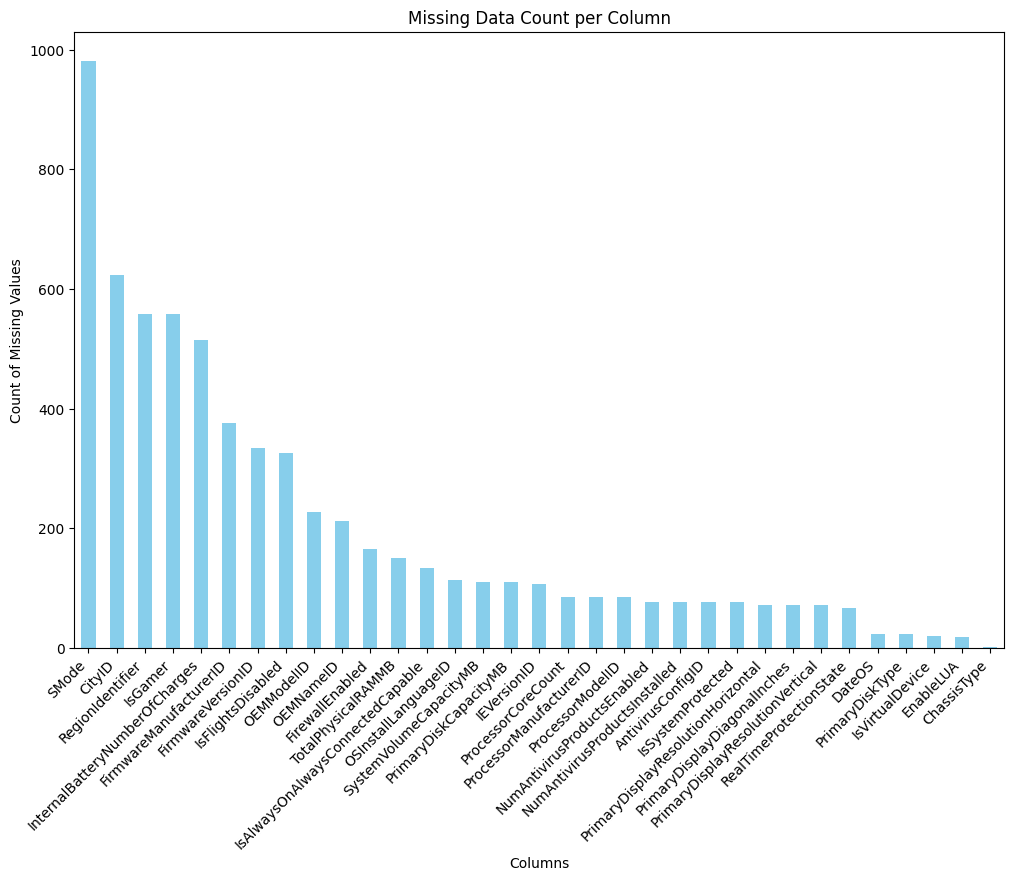

In [9]:
# Calculate missing values
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]  # Filter only columns with missing values

# Plot bar graph
plt.figure(figsize=(12, 8))
missing_data.plot(kind='bar', color='skyblue')
plt.title("Missing Data Count per Column")
plt.xlabel("Columns")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45, ha="right")
plt.show()



In [10]:
# num = df.select_dtypes(include = ['float64','int64']).columns.to_list()
# for col in num:
#     fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

#     # Boxplot
#     sns.boxplot(x=df[col], ax=axes[0])
#     axes[0].set_title(f'Boxplot of {col}')

#     # Histogram with KDE
#     sns.histplot(df[col], kde=True, bins=30, ax=axes[1])
#     axes[1].set_title(f'Distribution of {col}')

#     plt.show()

In [11]:
# cat = df.select_dtypes(include = ['object','category']).columns.to_list()
# threshold = 0.05 * len(df)  # Categories with <5% frequency are grouped as "Other"
# dfc = df.copy()
# for col in cat:
#     plt.figure(figsize=(10, 4))

#     # Replace rare categories with "Other"
#     top_categories = dfc[col].value_counts()
#     dfc[col] = np.where(dfc[col].isin(top_categories[top_categories >= threshold].index), df[col], "Other")

#     sns.countplot(x=df[col], palette='Set3', order=dfc[col].value_counts().index)

#     plt.title(f'Category Distribution (Grouped) - {col}')
#     plt.xticks(rotation=45)
#     plt.show()


# Correlation Distribution

In [12]:
# Select numerical columns (including target)
numeric_cols = df.select_dtypes(include=['float64', 'int64','int32'])

# Compute correlation of each feature with the target column
target_corr = numeric_cols.corr()['target'].sort_values(ascending=False)

# Print the correlation with target
print("Correlation with target:")
print(target_corr)

# Create a list of columns with correlation below the threshold
correlation_threshold = 0.01 
high_corr_columns = target_corr[target_corr.abs() > 0.05].index.tolist()
low_corr = target_corr[target_corr.abs() < correlation_threshold].index.tolist()

Correlation with target:
target                                1.000000
AntivirusConfigID                     0.118304
TotalPhysicalRAMMB                    0.065747
IsSystemProtected                     0.062401
IsGamer                               0.061191
ProcessorCoreCount                    0.056769
PrimaryDiskCapacityMB                 0.049117
RealTimeProtectionState               0.049012
OSBuildNumberOnly                     0.038544
PrimaryDisplayDiagonalInches          0.035064
OSBuildNumber                         0.034712
PrimaryDisplayResolutionHorizontal    0.030559
IEVersionID                           0.023820
HasOpticalDiskDrive                   0.022328
ProcessorModelID                      0.021678
InternalBatteryNumberOfCharges        0.017066
LocaleEnglishNameID                   0.015487
SystemVolumeCapacityMB                0.013870
PrimaryDisplayResolutionVertical      0.011202
FirewallEnabled                       0.010266
HasTpm                             

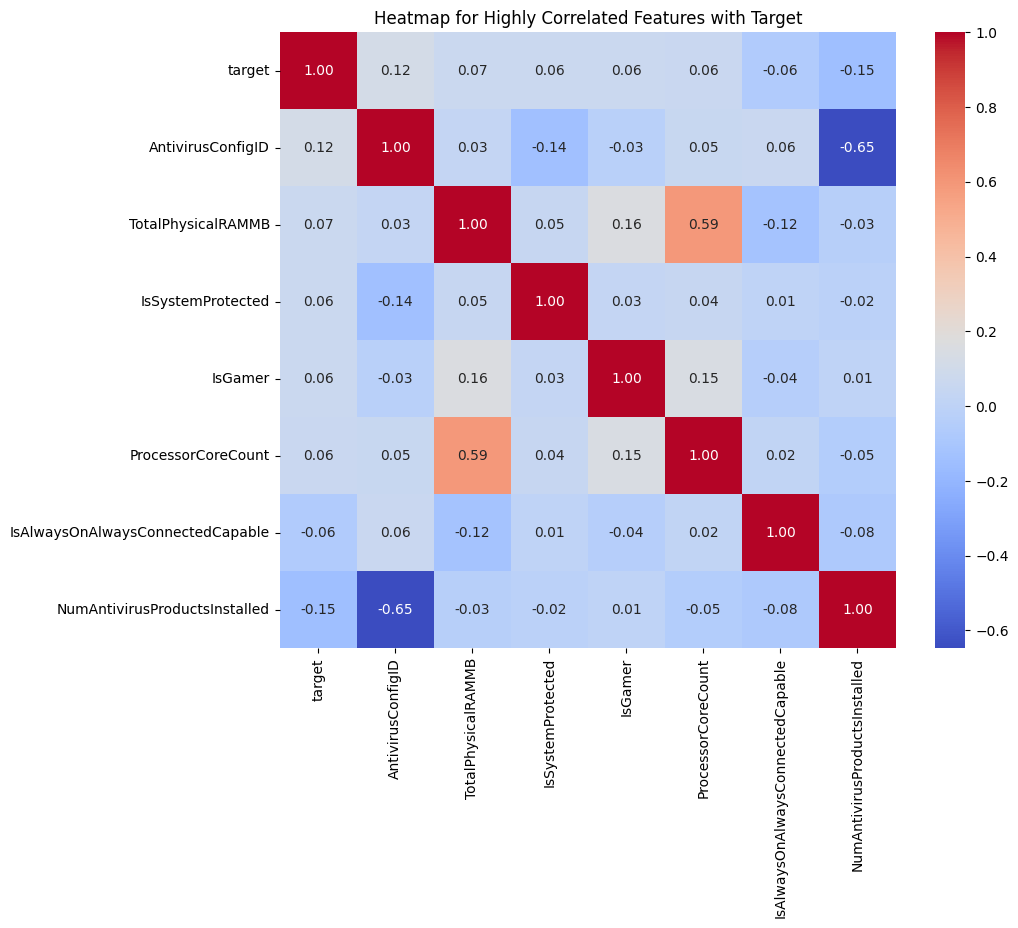

In [13]:
# Compute the correlation matrix of the selected high correlation features (including target)
high_corr_matrix = numeric_cols[high_corr_columns].corr()

# Plot heatmap for the high correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(high_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap for Highly Correlated Features with Target")
plt.show()

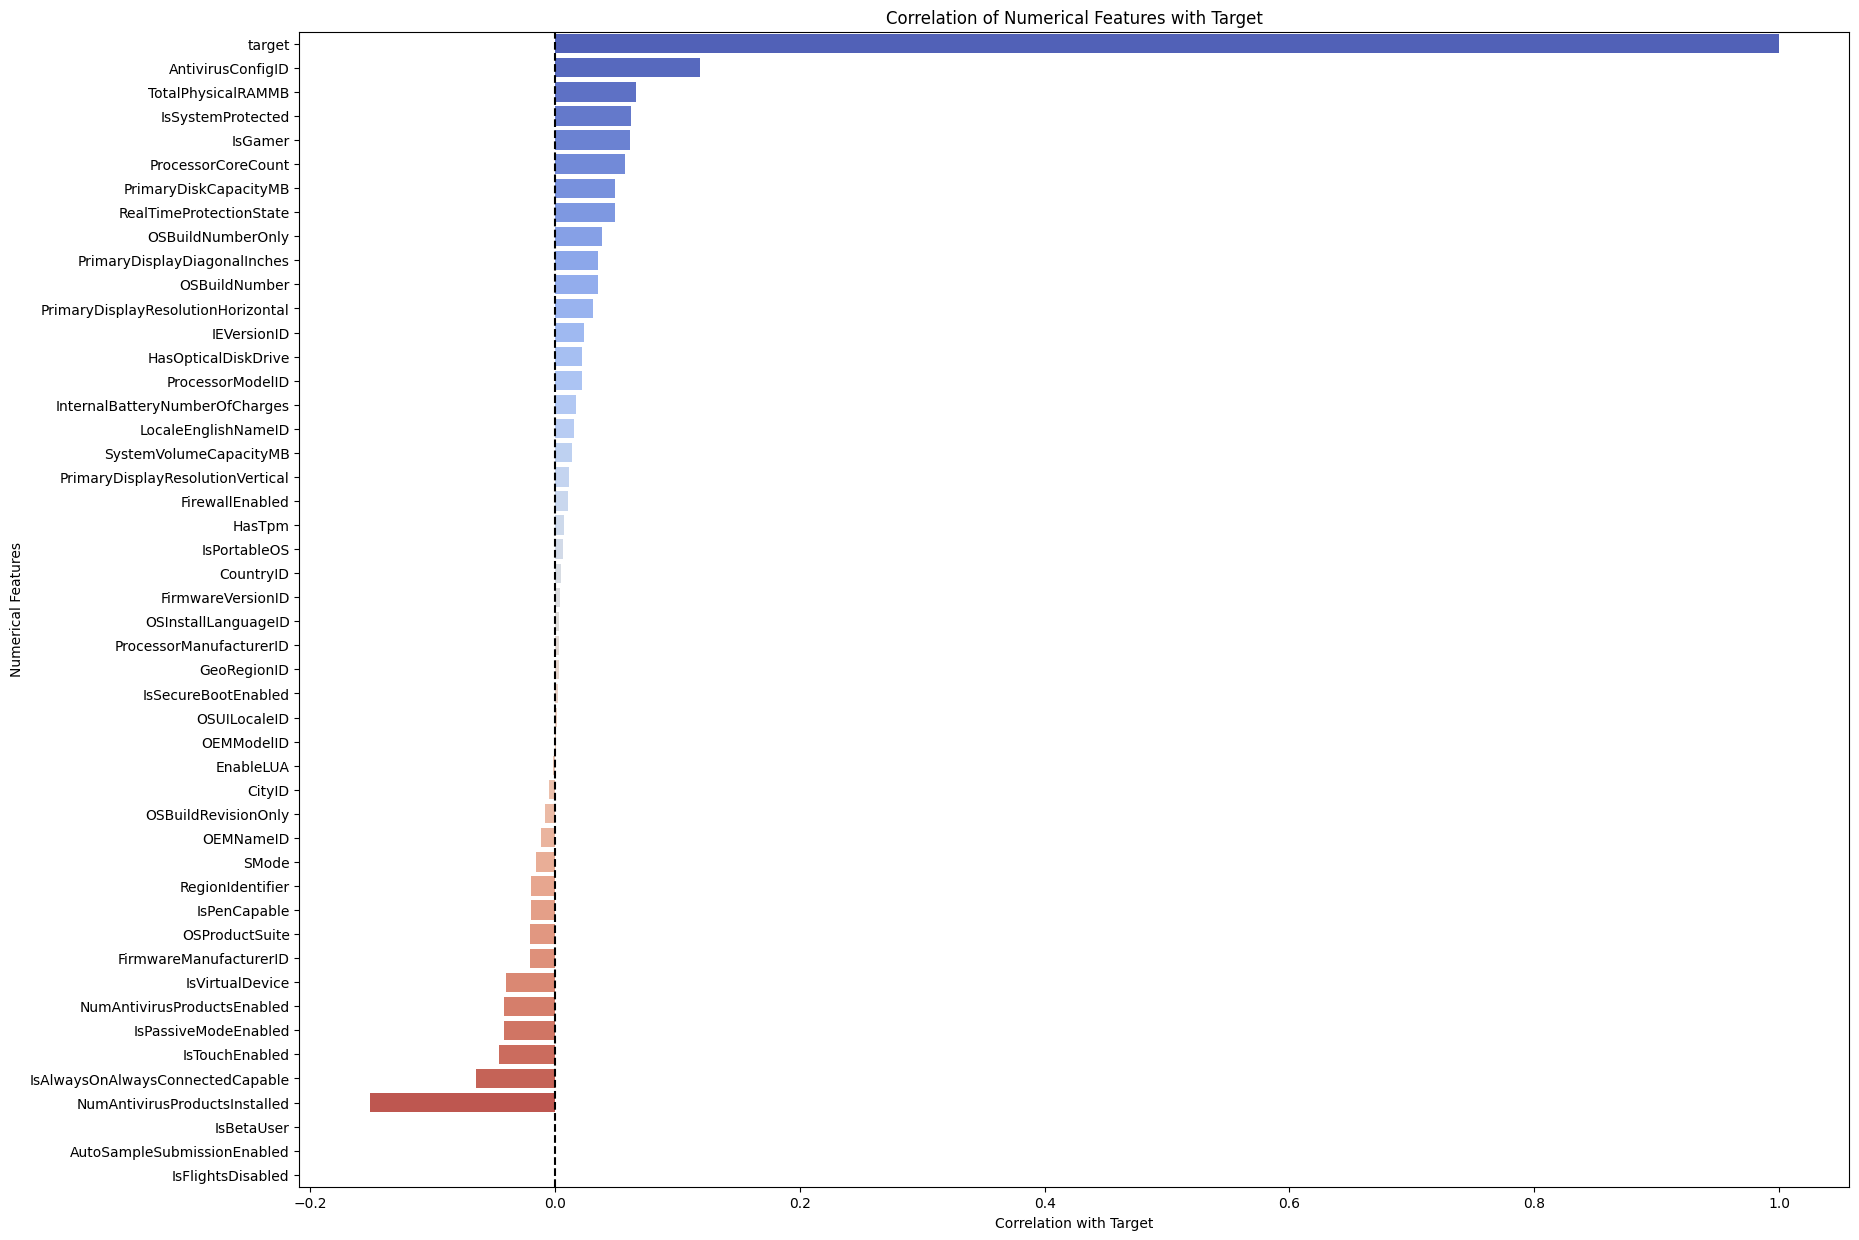

In [14]:
# Convert correlation series to DataFrame for plotting
target_corr_df = target_corr.reset_index()
target_corr_df.columns = ["Feature", "Correlation"]

# Plot correlation results
plt.figure(figsize=(20, 15))
sns.barplot(
    data=target_corr_df, 
    x="Correlation", 
    y="Feature", 
    palette="coolwarm"
)

plt.axvline(x=0, color='black', linestyle='--')  # Add a vertical line at 0
plt.xlabel("Correlation with Target")
plt.ylabel("Numerical Features")
plt.title("Correlation of Numerical Features with Target")
plt.show()

In [15]:
from sklearn.feature_selection import f_classif, mutual_info_regression

def categorical_target_correlation(df, categorical_cols, target_col):
    """
    Computes correlation between categorical features and a numerical target.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        categorical_cols (list): List of categorical column names.
        target_col (str): Name of the numerical target column.

    Returns:
        pd.DataFrame: Correlation scores (higher = stronger relationship).
    """
    correlation_results = {}

    for col in categorical_cols:
        if df[col].dtype == 'object' or df[col].dtype.name == 'category' or df[col].nunique() > 1:
            # Mean Encoding
            mean_encoded = df[col].map(df.groupby(col)[target_col].mean())

            corr_value = df[target_col].corr(mean_encoded)

            correlation_results[col] = corr_value

    return pd.DataFrame(correlation_results.items(), columns=['Feature', 'Correlation']).sort_values(by='Correlation', ascending=False)


categorical_cols = df.select_dtypes(include=['object']).columns.to_list()
correlation_df = categorical_target_correlation(df, categorical_cols, "target")
print(correlation_df)

                     Feature  Correlation
3           SignatureVersion     0.220303
25                    DateAS     0.219237
1              EngineVersion     0.134739
2                 AppVersion     0.119766
8                 OSBuildLab     0.107529
15          NumericOSVersion     0.097580
26                    DateOS     0.084069
10            MDC2FormFactor     0.076098
5                  Processor     0.073558
16            OSArchitecture     0.072950
14         PowerPlatformRole     0.067266
17                  OSBranch     0.064313
13               ChassisType     0.060128
20             OSInstallType     0.055173
7       OsPlatformSubRelease     0.051050
23  LicenseActivationChannel     0.050578
18                 OSEdition     0.049090
19         OSSkuFriendlyName     0.048149
21     AutoUpdateOptionsName     0.038232
12           PrimaryDiskType     0.026438
9             SKUEditionName     0.023086
22            OSGenuineState     0.012242
4               PlatformType     0

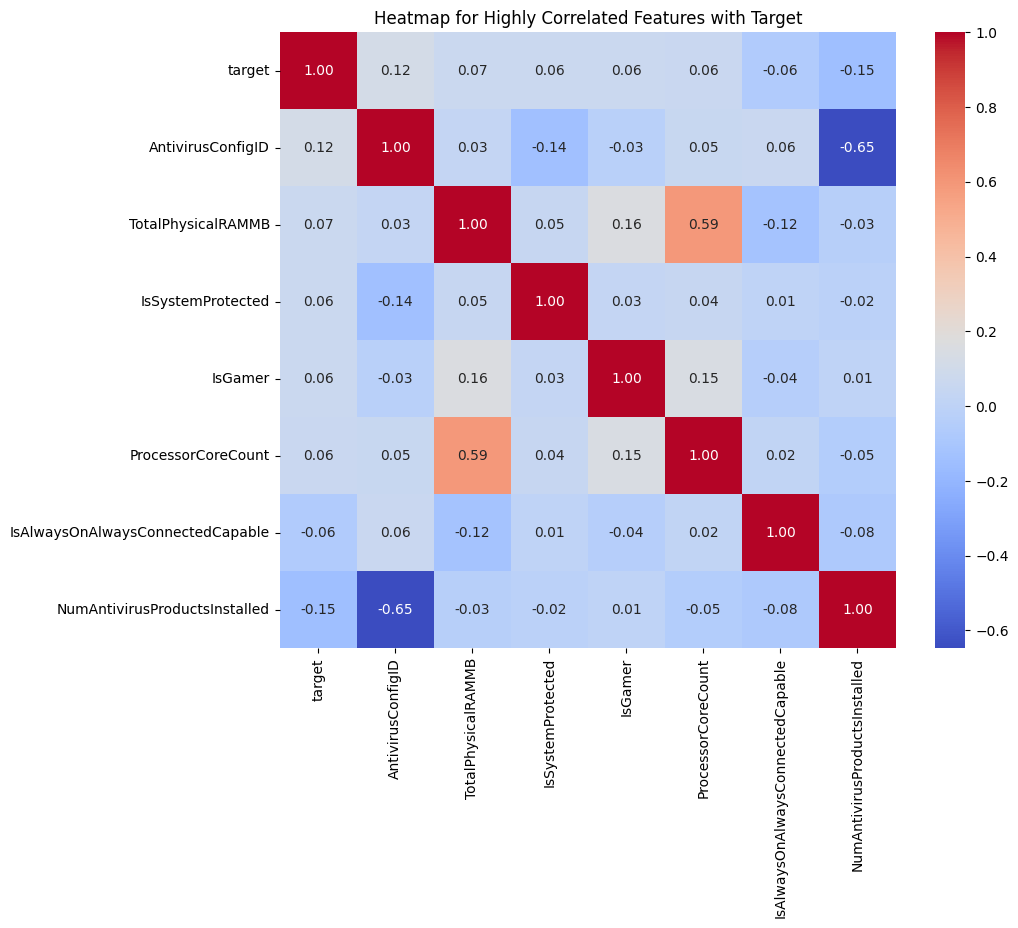

In [16]:
# Compute the correlation matrix of the selected high correlation features (including target)
high_corr_matrix = numeric_cols[high_corr_columns].corr()

# Plot heatmap for the high correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(high_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap for Highly Correlated Features with Target")
plt.show()

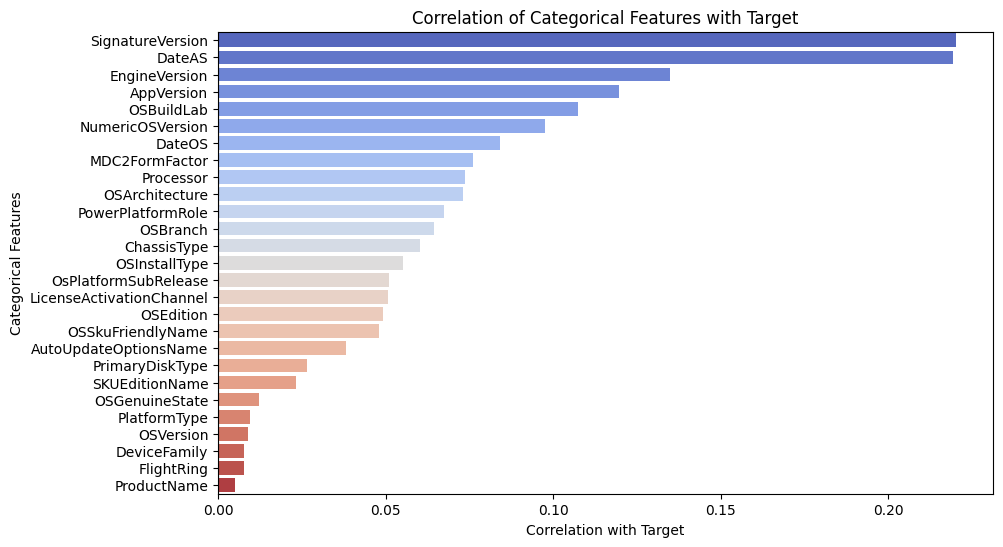

In [17]:
# Plot correlation results
plt.figure(figsize=(10, 6))
sns.barplot(
    data=correlation_df, 
    x="Correlation", 
    y="Feature", 
    palette="coolwarm"
)

plt.axvline(x=0, color='black', linestyle='--')  # Add a vertical line at 0
plt.xlabel("Correlation with Target")
plt.ylabel("Categorical Features")
plt.title("Correlation of Categorical Features with Target")
plt.show()

# Handling Missing Values

In [18]:
print(f"Training : {df.shape}\nTest : {dft.shape}")

Training : (100000, 75)
Test : (10000, 74)


In [19]:
to_remove = ['MachineID', 'CountryID', 'CityID', 'GeoRegionID', 'OEMNameID', 'OEMModelID', 'ProcessorManufacturerID', 'OSInstallLanguageID', 'OSUILocaleID', 'FirmwareManufacturerID', 'FirmwareVersionID']
low_catcorr = ["PlatformType","OSVersion","DeviceFamily","FlightRing","ProductName"]

# Remove features with low correlation
to_remove1 = list(set(to_remove+low_corr+low_catcorr))
df_r = df.drop(columns=to_remove1, errors='ignore')  # errors='ignore' to avoid errors if columns are missing
dft_r = dft.drop(columns=to_remove1, errors='ignore')
Xr = df_r.drop("target",axis=1)
yr = df_r["target"]
print("Updated df shape:", df_r.shape)
print("Updated dft shape:", dft_r.shape)

Updated df shape: (100000, 55)
Updated dft shape: (10000, 54)


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MaxAbsScaler, MinMaxScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

In [21]:
def impute(a):
    cat = a.select_dtypes(include=['object']).columns.to_list()
    num = a.select_dtypes(include=['float64', 'int64']).columns.to_list()
    df = a.copy()
    if cat:
        cat_imputer = SimpleImputer(strategy='most_frequent')  
        df[cat] = cat_imputer.fit_transform(df[cat])
    if num:
        knn_imputer = KNNImputer(n_neighbors=5)  # Adjust neighbors as needed
        df[num] = knn_imputer.fit_transform(df[num])
    
    return df

df = df.dropna()
X = df.drop("target",axis=1)
y=df["target"]
dft = impute(dft)
print(f"Training : {X.isna().sum().sum()}\nTest : {dft.isna().sum().sum()}")
dfr = impute(df_r)
dftr = impute(dft_r)
print(f"Training1 : {dfr.isna().sum().sum()}\nTest1 : {dftr.isna().sum().sum()}")

Training : 0
Test : 0
Training1 : 0
Test1 : 0


In [22]:
num = X.select_dtypes(include = ['float64','int64','int32']).columns.to_list()
low = []
mid = []
high = []
for col in num:
    if X[col].nunique() <= 20:
        low.append(col)
    elif X[col].nunique() <= 250:
        mid.append(col)
    else:
        high.append(col)
l = ['IEVersionID', 'TotalPhysicalRAMMB', 'PrimaryDisplayResolutionHorizontal', 'PrimaryDisplayResolutionVertical', 'OSBuildRevisionOnly']
high = high + l
mid1 = [col for col in mid if col not in l]
low = low+mid1

In [23]:
# pd.option_context('mode.use_inf_as_na', True)
# plt.figure(figsize=(15, 20))
# for i, col in enumerate(mid, 1):
#     plt.subplot(len(mid) // 4 + 1, 4, i)
#     sns.histplot(X[col], kde=True)  # kde=True adds a density curve
#     plt.title(col)
#     plt.tight_layout()

# plt.show()

# Encoding Categorical Features and Scaling

In [24]:
def frequency_encode(df, dft, cols):
    for col in cols:
        freq = df[col].value_counts(normalize=True)
        df[col] = df[col].map(freq)
        dft[col] = dft[col].map(freq).fillna(0)  # Handle unseen values in test set
    return df, dft

In [25]:
cat = X.select_dtypes(include=['object', 'category']).columns.to_list()

cat1 = ["SignatureVersion","OSBuildLab","NumericOSVersion","DateAS","DateOS"]
cat2 = [col for col in cat if col not in cat1]

In [26]:
def encode(a: pd.DataFrame, b: pd.DataFrame, cat1: list, cat2: list):
    df = a.copy()
    dft = b.copy()

    # Ordinal Encoding for cat1
    if cat1:
        ord_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        df[cat1] = ord_encoder.fit_transform(df[cat1])
        dft[cat1] = ord_encoder.transform(dft[cat1])

    # One-Hot Encoding for cat2
    if cat2:
        ohe_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False, dtype=np.float64)
        df_ohe = pd.DataFrame(ohe_encoder.fit_transform(df[cat2]), columns=ohe_encoder.get_feature_names_out(cat2), index=df.index)
        dft_ohe = pd.DataFrame(ohe_encoder.transform(dft[cat2]), columns=ohe_encoder.get_feature_names_out(cat2), index=dft.index)

        # Drop original categorical columns and add one-hot encoded ones
        df = df.drop(columns=cat2).join(df_ohe)
        dft = dft.drop(columns=cat2).join(dft_ohe)

    # Scale entire dataset (both categorical and numerical after encoding)
    scaler = MinMaxScaler()
    df[df.columns] = scaler.fit_transform(df)
    dft[dft.columns] = scaler.transform(dft)

    return df, dft

X, dft = frequency_encode(X, dft, low)
X, dft = encode(X, dft, cat1, cat2)
print(f"Updated shape after Encoding:\nTraining: {X.shape}\nTest: {dft.shape}")

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Updated shape after Encoding:
Training: (96695, 310)
Test: (10000, 310)


In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def woe_encoder(train_df, test_df, epsilon=1e-6, min_freq=10, alpha=0.1, clip_value=2):
    """
    Weight of Evidence (WoE) Encoding with Shrinkage Regularization, Frequency Thresholding,
    and Clipping to Reduce Overfitting.

    Parameters:
    - train_df: Training DataFrame (must contain 'target' column).
    - test_df: Test DataFrame.
    - epsilon: Smoothing term to avoid division by zero.
    - min_freq: Minimum frequency threshold for rare categories.
    - alpha: Shrinkage factor for regularization.
    - clip_value: Clip extreme WoE values to reduce overfitting.

    Returns:
    - Encoded and scaled train and test DataFrames.
    """
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    
    cat_cols = train_df.select_dtypes(include=['object']).columns  # Identify categorical columns

    for col in cat_cols:
        # Handle missing values by treating them as a separate category
        train_encoded[col] = train_encoded[col].fillna('Missing')
        test_encoded[col] = test_encoded[col].fillna('Missing')

        # Frequency thresholding — combine rare categories into "Other"
        counts = train_encoded[col].value_counts()
        rare_cats = counts[counts < min_freq].index
        train_encoded[col] = train_encoded[col].replace(rare_cats, 'Other')
        test_encoded[col] = test_encoded[col].replace(rare_cats, 'Other')

        # Compute category statistics
        category_stats = train_encoded.groupby(col)["target"].agg(["sum", "count"])
        
        # P(positive) and P(negative) with smoothing
        p_pos = (category_stats["sum"] + epsilon) / (train_encoded["target"].sum() + epsilon)
        p_neg = ((category_stats["count"] - category_stats["sum"]) + epsilon) / ((train_encoded.shape[0] - train_encoded["target"].sum()) + epsilon)
        
        # Compute raw WoE values
        raw_woe = np.log(p_pos / p_neg)
        
        # Shrinkage regularization: Blend raw WoE with global mean WoE
        global_woe = np.log((train_encoded["target"].mean() + epsilon) / (1 - train_encoded["target"].mean() + epsilon))
        woe_values = alpha * raw_woe + (1 - alpha) * global_woe
        
        # Clip extreme WoE values to avoid overfitting
        woe_values = woe_values.clip(-clip_value, clip_value)

        # Replace categories with WoE values
        train_encoded[col] = train_encoded[col].map(woe_values)
        test_encoded[col] = test_encoded[col].map(woe_values)

        # Handle unseen categories in test set by assigning global mean WoE
        test_encoded[col].fillna(global_woe, inplace=True)

    # Separate features and target before scaling
    target = train_encoded["target"]
    train_features = train_encoded.drop(columns=["target"])
    test_features = test_encoded  # No target column in test set
    
    # Ensure all values are numeric
    train_features = train_features.astype(float)
    test_features = test_features.astype(float)

    # Standard Scale the features
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_features)
    test_scaled = scaler.transform(test_features)

    # Convert back to DataFrame
    train_scaled_df = pd.DataFrame(train_scaled, columns=train_features.columns, index=train_df.index)
    test_scaled_df = pd.DataFrame(test_scaled, columns=test_features.columns, index=test_df.index)

    # Add target column back to train set
    train_scaled_df["target"] = target

    print(f"Train Encoded & Scaled Shape: {train_scaled_df.shape}")
    print(f"Test Encoded & Scaled Shape: {test_scaled_df.shape}")

    return train_scaled_df, test_scaled_df

In [28]:
df_en,dft_en = woe_encoder(dfr,dftr)
X_en = df_en.drop("target",axis=1)
y_en = df_en["target"]

Train Encoded & Scaled Shape: (100000, 55)
Test Encoded & Scaled Shape: (10000, 54)


# Dummy(BaseLine) Model

In [29]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size=0.1,random_state=42)
print(xtrain.shape,xtest.shape)

model = DummyClassifier(strategy="most_frequent")
model.fit(xtrain,ytrain)
ypred = model.predict(xtest)
print(accuracy_score(ytest,ypred))
print(classification_report(ytest,ypred))

(87025, 310) (9670, 310)
0.5012409513960703
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4823
           1       0.50      1.00      0.67      4847

    accuracy                           0.50      9670
   macro avg       0.25      0.50      0.33      9670
weighted avg       0.25      0.50      0.33      9670



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Feature Selection

In [30]:
from sklearn.linear_model import Lasso

def select_lasso(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, alpha: float = 0.00009):
    """
    Perform Lasso feature selection and return the reduced datasets with selected features.

    Parameters:
    - X_train (pd.DataFrame): Training feature matrix (excluding target column)
    - y_train (pd.Series): Training target column
    - X_test (pd.DataFrame): Test feature matrix (same columns as X_train)
    - alpha (float): Regularization strength for Lasso (default=0.001)

    Returns:
    - X_train_selected (pd.DataFrame): Training set with only selected features
    - X_test_selected (pd.DataFrame): Test set with only selected features
    - important_features (list): List of selected feature names
    """
    # Initialize Lasso model
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)

    # Get the selected features (non-zero coefficients)
    selected_features = X_train.columns[lasso.coef_ != 0]
    important_features = list(selected_features)

    # Reduce both training and test sets to selected features
    X_train_selected = X_train[important_features]
    X_test_selected = X_test[important_features]
    print(f"Selected Features : {len(important_features)} Original Features: {X_train.shape[1]}")

    return X_train_selected, X_test_selected, important_features

# Example Usage
X_lasso, dft_lasso, features_lasso = select_lasso(X,y,dft)

Selected Features : 120 Original Features: 310


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.183e+00, tolerance: 2.417e+00
  model = cd_fast.enet_coordinate_descent(


# Classification Models

Training : ((87025, 120), (87025,))
Test : ((9670, 120), (9670,))
Ridge Classifier Accuracy: 0.6247156153050673
              precision    recall  f1-score   support

           0       0.63      0.56      0.59      4738
           1       0.62      0.69      0.65      4932

    accuracy                           0.62      9670
   macro avg       0.63      0.62      0.62      9670
weighted avg       0.63      0.62      0.62      9670



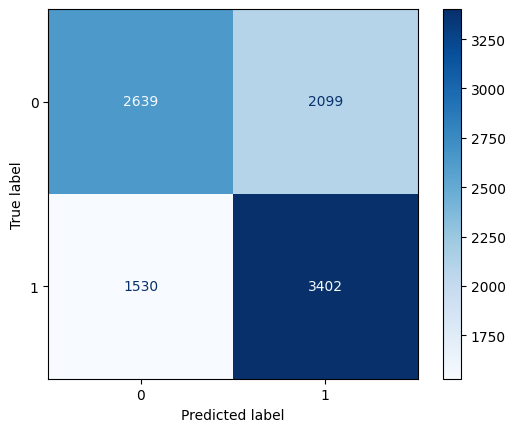

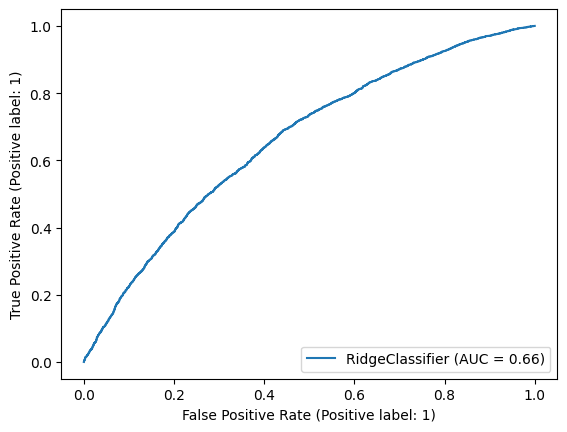

In [31]:
from sklearn.linear_model import RidgeClassifier

# Split into training and validation sets
xtrain, xval, ytrain, yval = train_test_split(X_lasso, y, test_size=0.1, random_state=19)
print(f"Training : {xtrain.shape, ytrain.shape}\nTest : {xval.shape, yval.shape}")

# Train Ridge Classifier
ridge = RidgeClassifier(alpha=1.0)
ridge.fit(xtrain, ytrain)

# Predict and evaluate
ypred_ridge = ridge.predict(xval)

# Output performance metrics
print("Ridge Classifier Accuracy:", accuracy_score(yval, ypred_ridge))
print(classification_report(yval, ypred_ridge))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(yval, ypred_ridge, cmap="Blues")

# ROC Curve Display
RocCurveDisplay.from_estimator(ridge, xval, yval)


Training : ((87025, 120), (87025,))
Test : ((9670, 120), (9670,))
GradientBoost Accuracy : 0.6292657704239917
              precision    recall  f1-score   support

           0       0.64      0.55      0.59      4703
           1       0.62      0.70      0.66      4967

    accuracy                           0.63      9670
   macro avg       0.63      0.63      0.63      9670
weighted avg       0.63      0.63      0.63      9670



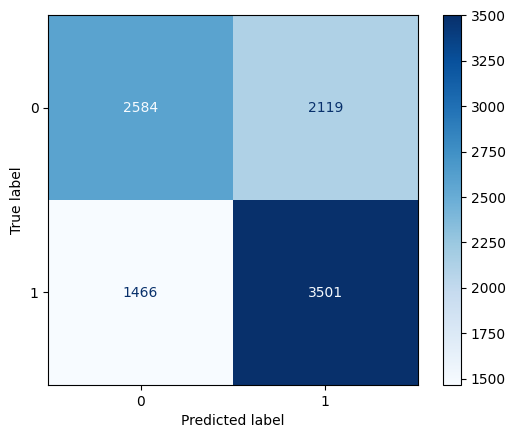

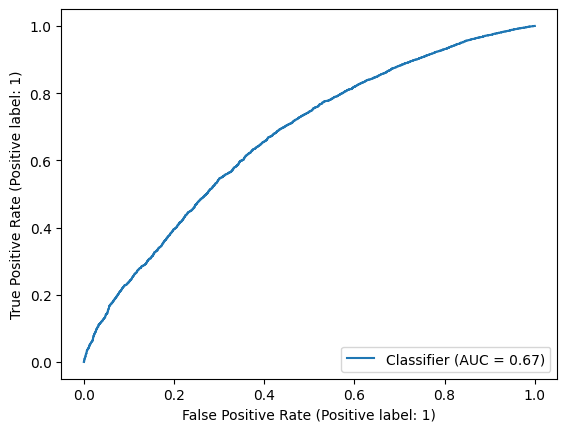

In [32]:
from sklearn.ensemble import GradientBoostingClassifier as GBC

# Split into training and validation sets
xtrain, xval, ytrain, yval = train_test_split(X_lasso, y, test_size=0.1, random_state=237)
print(f"Training : {xtrain.shape, ytrain.shape}\nTest : {xval.shape, yval.shape}")

# Train Gradient Boosting Classifier
gbcp = GBC(random_state=237)
gbcp.fit(xtrain, ytrain)

# Predict and evaluate
ypred = gbcp.predict(xval)
ypred_proba = gbcp.predict_proba(xval)[:, 1]  # Probabilities for ROC curve

# Output performance metrics
print(f"GradientBoost Accuracy : {accuracy_score(yval, ypred)}")
print(classification_report(yval, ypred))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(yval, ypred, cmap="Blues")

# ROC Curve Display
RocCurveDisplay.from_predictions(yval, ypred_proba)

Training : ((87025, 120), (87025,))
Test : ((9670, 120), (9670,))
HistGradientBoosting Classifier Accuracy: 0.6334022750775594
              precision    recall  f1-score   support

           0       0.64      0.58      0.61      4738
           1       0.63      0.69      0.66      4932

    accuracy                           0.63      9670
   macro avg       0.63      0.63      0.63      9670
weighted avg       0.63      0.63      0.63      9670



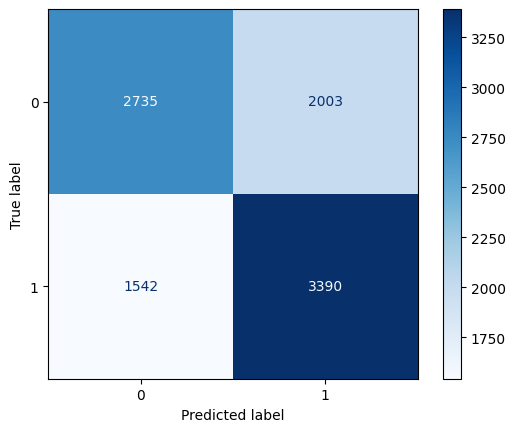

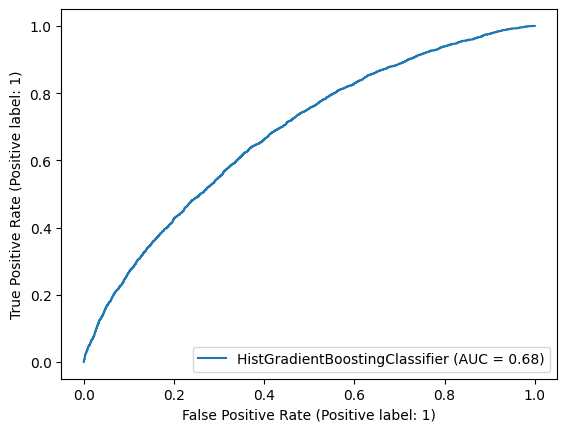

In [33]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Split into training and validation sets
xtrain, xval, ytrain, yval = train_test_split(X_lasso, y, test_size=0.1, random_state=19)
print(f"Training : {xtrain.shape, ytrain.shape}\nTest : {xval.shape, yval.shape}")

# Train HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    random_state=237
)

hgb.fit(xtrain, ytrain)

# Predict and evaluate
ypred_hgb = hgb.predict(xval)

# Output performance metrics
print("HistGradientBoosting Classifier Accuracy:", accuracy_score(yval, ypred_hgb))
print(classification_report(yval, ypred_hgb))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(yval, ypred_hgb, cmap="Blues")

# ROC Curve Display
RocCurveDisplay.from_estimator(hgb, xval, yval)

Training : ((87025, 310), (87025,))
Test : ((9670, 310), (9670,))
XGBoost Accuracy : 0.6358841778697001
              precision    recall  f1-score   support

           0       0.65      0.57      0.60      4738
           1       0.63      0.70      0.66      4932

    accuracy                           0.64      9670
   macro avg       0.64      0.63      0.63      9670
weighted avg       0.64      0.64      0.63      9670



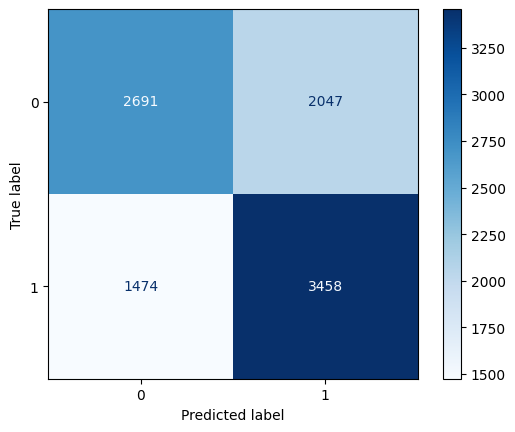

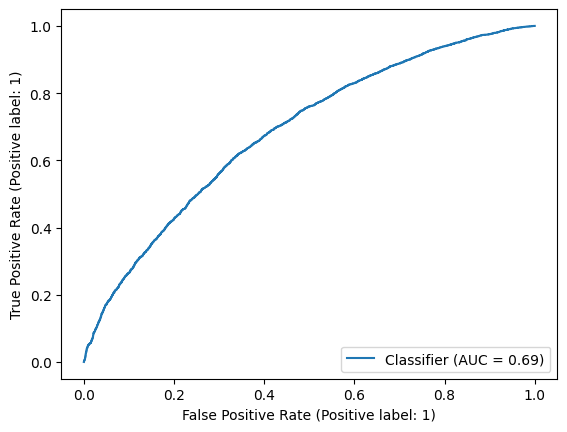

In [34]:
from xgboost import XGBClassifier

# Split into training and validation sets
xtrain, xval, ytrain, yval = train_test_split(X, y, test_size=0.1, random_state=19)
print(f"Training : {xtrain.shape, ytrain.shape}\nTest : {xval.shape, yval.shape}")

# Train XGBoost Classifier
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, random_state=237)
xgb.fit(xtrain, ytrain)

# Predict and evaluate
ypred = xgb.predict(xval)
ypred_proba = xgb.predict_proba(xval)[:, 1]  # Probabilities for ROC curve

# Output performance metrics
print(f"XGBoost Accuracy : {accuracy_score(yval, ypred)}")
print(classification_report(yval, ypred))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(yval, ypred, cmap="Blues")

# ROC Curve Display
RocCurveDisplay.from_predictions(yval, ypred_proba)

Training : ((87025, 310), (87025,))
Test : ((9670, 310), (9670,))


/usr/local/lib/python3.10/dist-packages/sklearn/calibration.py:321: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


XGBoost Classifier Accuracy (Calibrated): 0.6341261633919338
              precision    recall  f1-score   support

           0       0.63      0.60      0.61      4738
           1       0.63      0.67      0.65      4932

    accuracy                           0.63      9670
   macro avg       0.63      0.63      0.63      9670
weighted avg       0.63      0.63      0.63      9670



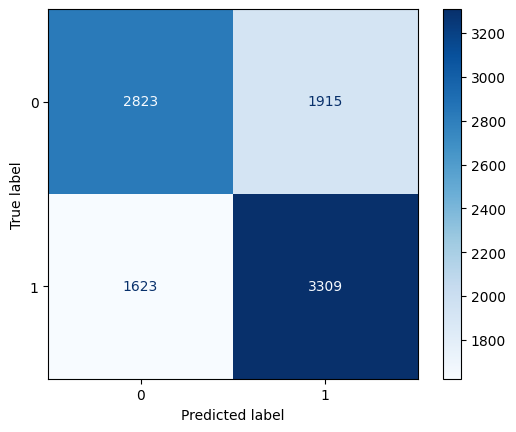

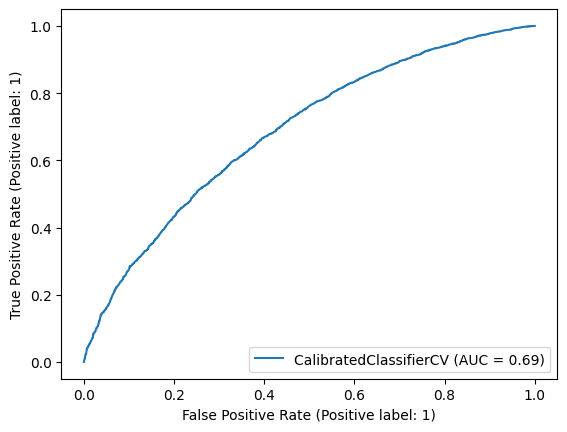

In [35]:
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

# Split into training and validation sets
xtrain, xval, ytrain, yval = train_test_split(X, y, test_size=0.1, random_state=19)
print(f"Training : {xtrain.shape, ytrain.shape}\nTest : {xval.shape, yval.shape}")

# Train XGBoost Classifier
xgb1 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    # max_depth=6,
    # min_child_weight=1,
    # subsample=0.7,
    # colsample_bytree=0.7,
    # gamma=0.1,
    random_state=237
)

xgb1.fit(xtrain, ytrain)

# Wrap XGBoost with CalibratedClassifierCV (calibrate on training set)
calibrated_xgb = CalibratedClassifierCV(base_estimator=xgb1, method='isotonic', cv=3)
calibrated_xgb.fit(xtrain, ytrain)  # Fit calibration on training data

# Predict on validation set
ypred_xgb = calibrated_xgb.predict(xval)

# Output performance metrics
print("XGBoost Classifier Accuracy (Calibrated):", accuracy_score(yval, ypred_xgb))
print(classification_report(yval, ypred_xgb))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(yval, ypred_xgb, cmap="Blues")

# ROC Curve Display
RocCurveDisplay.from_estimator(calibrated_xgb, xval, yval)

In [36]:
Xc = X.copy()
dftc = dft.copy()
# Rename columns to simple names (e.g., f1, f2, ...)
Xc.columns = [f"f{i}" for i in range(Xc.shape[1])]
dftc.columns = [f"f{i}" for i in range(dftc.shape[1])]

Training : ((87025, 310), (87025,))
Test : ((9670, 310), (9670,))
[LightGBM] [Info] Number of positive: 44002, number of negative: 43023
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044182 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4749
[LightGBM] [Info] Number of data points in the train set: 87025, number of used features: 232
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505625 -> initscore=0.022500
[LightGBM] [Info] Start training from score 0.022500
LGBM Accuracy : 0.6345398138572906
              precision    recall  f1-score   support

           0       0.64      0.58      0.61      4703
           1       0.63      0.69      0.66      4967

    accuracy                           0.63      9670
   macro avg       0.63      0.63      0.63      9670
weighted avg       0.63      0.63      0.63      9670



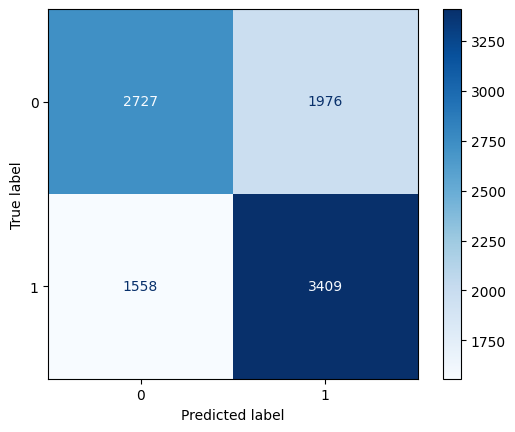

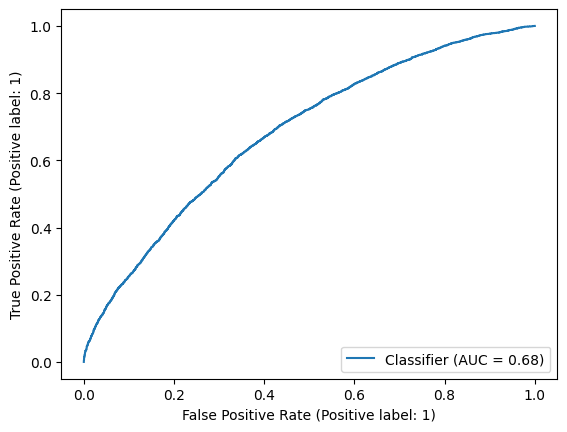

In [37]:
from lightgbm import LGBMClassifier

xtrain, xval, ytrain, yval = train_test_split(Xc, y, test_size=0.1, random_state=237)
print(f"Training : {xtrain.shape, ytrain.shape}\nTest : {xval.shape, yval.shape}")

lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=237)
lgbm.fit(xtrain, ytrain)

ypred = lgbm.predict(xval)
ypred_prob = lgbm.predict_proba(xval)[:, 1]  # Probability for positive class

print(f"LGBM Accuracy : {accuracy_score(yval, ypred)}")
print(classification_report(yval, ypred))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(yval, ypred,cmap="Blues")

# Display ROC Curve
RocCurveDisplay.from_predictions(yval, ypred_prob)

# Classification Models(using WoE)

Training : ((90000, 54), (90000,))
Test : ((10000, 54), (10000,))
GradientBoost Accuracy : 0.6326
              precision    recall  f1-score   support

         0.0       0.64      0.58      0.61      4905
         1.0       0.63      0.68      0.65      5095

    accuracy                           0.63     10000
   macro avg       0.63      0.63      0.63     10000
weighted avg       0.63      0.63      0.63     10000



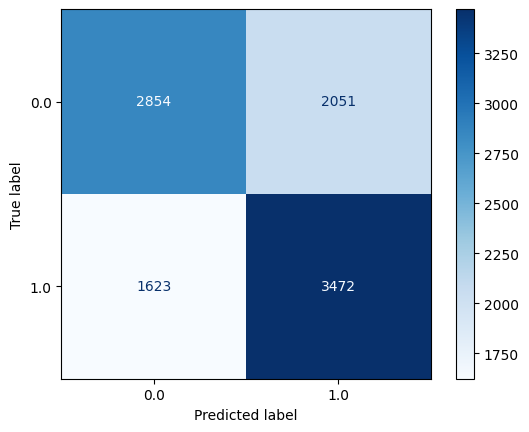

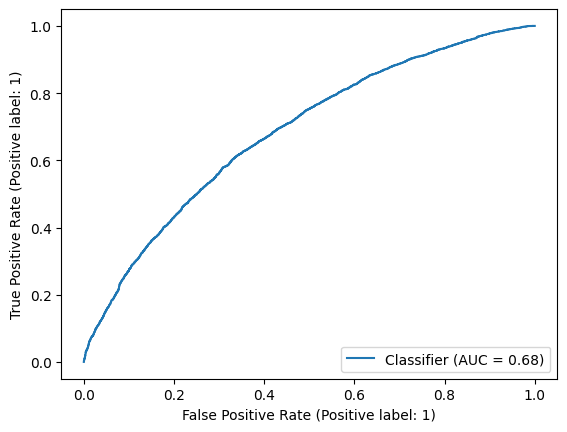

In [38]:
from sklearn.ensemble import GradientBoostingClassifier as GBC

# Split into training and validation sets
xtrain, xval, ytrain, yval = train_test_split(X_en, y_en, test_size=0.1, random_state=237)
print(f"Training : {xtrain.shape, ytrain.shape}\nTest : {xval.shape, yval.shape}")

# Train Gradient Boosting Classifier
gbc_e = GBC(random_state=237)
gbc_e.fit(xtrain, ytrain)

# Predict and evaluate
ypred = gbc_e.predict(xval)
ypred_proba = gbc_e.predict_proba(xval)[:, 1]  # Probabilities for ROC curve

# Output performance metrics
print(f"GradientBoost Accuracy : {accuracy_score(yval, ypred)}")
print(classification_report(yval, ypred))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(yval, ypred, cmap="Blues")

# ROC Curve Display
RocCurveDisplay.from_predictions(yval, ypred_proba)

Training : ((90000, 54), (90000,))
Test : ((10000, 54), (10000,))
HistGradientBoosting Classifier Accuracy: 0.6362
              precision    recall  f1-score   support

         0.0       0.64      0.60      0.62      4919
         1.0       0.63      0.67      0.65      5081

    accuracy                           0.64     10000
   macro avg       0.64      0.64      0.64     10000
weighted avg       0.64      0.64      0.64     10000



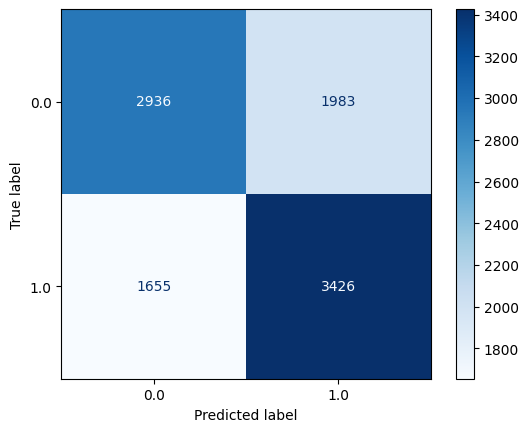

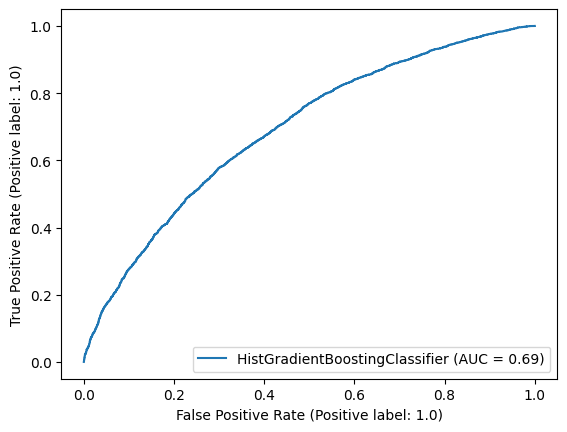

In [39]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Split into training and validation sets
xtrain, xval, ytrain, yval = train_test_split(X_en, y_en, test_size=0.1, random_state=19)
print(f"Training : {xtrain.shape, ytrain.shape}\nTest : {xval.shape, yval.shape}")

# Train HistGradientBoostingClassifier
hgb_e = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    random_state=237
)

hgb_e.fit(xtrain, ytrain)

# Predict and evaluate
ypred_hgb = hgb_e.predict(xval)

# Output performance metrics
print("HistGradientBoosting Classifier Accuracy:", accuracy_score(yval, ypred_hgb))
print(classification_report(yval, ypred_hgb))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(yval, ypred_hgb, cmap="Blues")

# ROC Curve Display
RocCurveDisplay.from_estimator(hgb_e, xval, yval)


Training : ((90000, 54), (90000,))
Test : ((10000, 54), (10000,))
XGBoost Accuracy : 0.6425
              precision    recall  f1-score   support

         0.0       0.65      0.60      0.62      4905
         1.0       0.64      0.69      0.66      5095

    accuracy                           0.64     10000
   macro avg       0.64      0.64      0.64     10000
weighted avg       0.64      0.64      0.64     10000



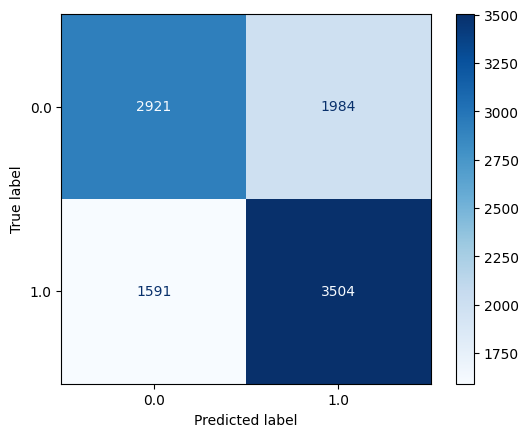

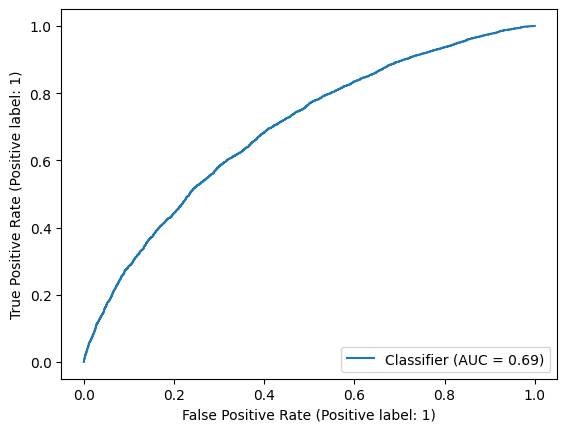

In [40]:
from xgboost import XGBClassifier

xtrain, xval, ytrain, yval = train_test_split(X_en, y_en, test_size=0.1, random_state=237)
print(f"Training : {xtrain.shape, ytrain.shape}\nTest : {xval.shape, yval.shape}")

xgb_e = XGBClassifier(n_estimators=200, learning_rate=0.05, random_state=237)
xgb_e.fit(xtrain, ytrain)

ypred = xgb_e.predict(xval)
ypred_prob = xgb_e.predict_proba(xval)[:, 1]  # Probability for positive class

print(f"XGBoost Accuracy : {accuracy_score(yval, ypred)}")
print(classification_report(yval, ypred))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(yval, ypred,cmap="Blues")

# Display ROC Curve
RocCurveDisplay.from_predictions(yval, ypred_prob)

Training : ((90000, 54), (90000,))
Test : ((10000, 54), (10000,))
[LightGBM] [Info] Number of positive: 45430, number of negative: 44570
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013369 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3077
[LightGBM] [Info] Number of data points in the train set: 90000, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.504778 -> initscore=0.019112
[LightGBM] [Info] Start training from score 0.019112
LGBM Accuracy : 0.6426
              precision    recall  f1-score   support

         0.0       0.64      0.61      0.62      4905
         1.0       0.64      0.68      0.66      5095

    accuracy                           0.64     10000
   macro avg       0.64      0.64      0.64     10000
weighted avg       0.64      0.64      0.64     10000



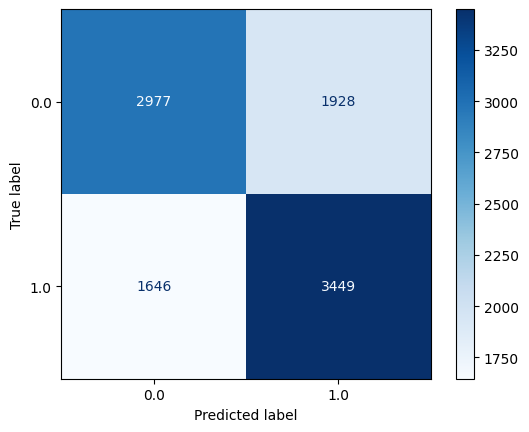

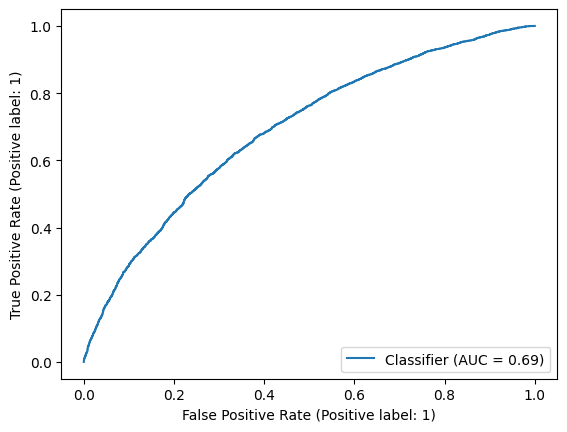

In [41]:
from lightgbm import LGBMClassifier

xtrain, xval, ytrain, yval = train_test_split(X_en, y_en, test_size=0.1, random_state=237)
print(f"Training : {xtrain.shape, ytrain.shape}\nTest : {xval.shape, yval.shape}")

lgbm_e = LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=237)
lgbm_e.fit(xtrain, ytrain)

ypred = lgbm_e.predict(xval)
ypred_prob = lgbm_e.predict_proba(xval)[:, 1]  # Probability for positive class

print(f"LGBM Accuracy : {accuracy_score(yval, ypred)}")
print(classification_report(yval, ypred))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(yval, ypred,cmap="Blues")

# Display ROC Curve
RocCurveDisplay.from_predictions(yval, ypred_prob)

Training : ((87025, 310), (87025,))
Test : ((9670, 310), (9670,))
Stacking Classifier Accuracy: 0.636918304033092
              precision    recall  f1-score   support

           0       0.64      0.58      0.61      4738
           1       0.63      0.69      0.66      4932

    accuracy                           0.64      9670
   macro avg       0.64      0.64      0.64      9670
weighted avg       0.64      0.64      0.64      9670



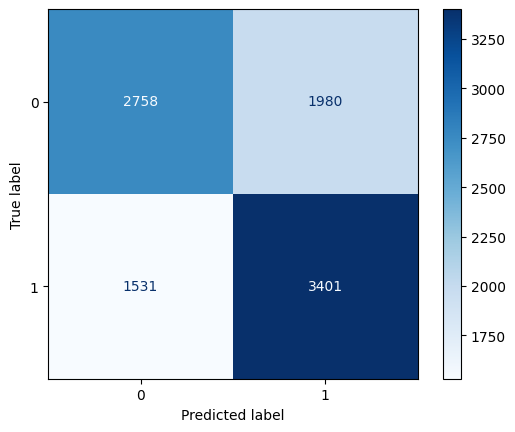

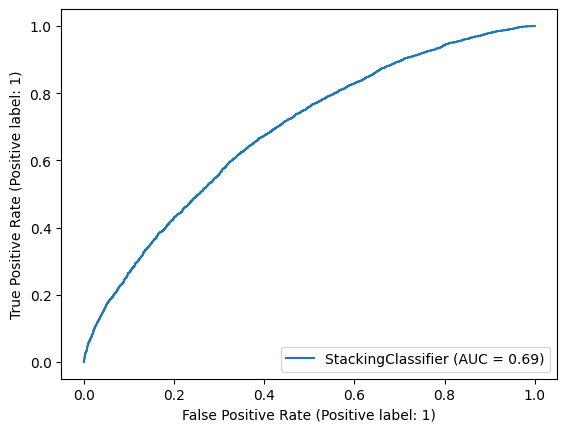

In [42]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Split into training and validation sets
xtrain, xval, ytrain, yval = train_test_split(X, y, test_size=0.1, random_state=19)
print(f"Training : {xtrain.shape, ytrain.shape}\nTest : {xval.shape, yval.shape}")

# Define base models
ridge = RidgeClassifier(alpha=1.0)
gdb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=237)
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, random_state=237)

# Stacking Classifier
stack = StackingClassifier(
    estimators=[
        ('ridge', ridge),
        ('gdb', gdb),
        ('xgb', xgb)
    ],
    final_estimator=XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=237),
    passthrough=True
)

# Train Stacking Classifier
stack.fit(xtrain, ytrain)

# Predict and evaluate
ypred_stack = stack.predict(xval)

# Output performance metrics
print("Stacking Classifier Accuracy:", accuracy_score(yval, ypred_stack))
print(classification_report(yval, ypred_stack))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(yval, ypred_stack, cmap="Blues")

# ROC Curve Display
RocCurveDisplay.from_estimator(stack, xval, yval)

# Submission Files

In [43]:
ypred = stack.predict(dft)
submission = pd.DataFrame({
    "id" : range(0,dft.shape[0]),
    "target" : ypred
})
submission.to_csv("submission.csv",index=False)
print(submission[19:23])
submission["target"].value_counts()

    id  target
19  19       1
20  20       0
21  21       0
22  22       1


target
1    5497
0    4503
Name: count, dtype: int64